In [1]:
import os
import sys
import json
sys.path.append("..")

from CalixVolApp.calculation.visualization import MoleculeData, VisualizationCavityWithConvex, PointsInAtomsPlot, HullMoleculePlot
from CalixVolApp.calculation.calculation import MoleculeFileReader, JsonVDWRadiusProvider, ConvexHullVolumeEstimator, MoleculeVolumeCalculator
from CalixVolApp.utils.paths import get_project_path

In [2]:
def init_parms(molecule_file_path):
    vdw_file = os.path.join(get_project_path(), 'CalixVolApp', 'data', 'vdw', 'vdw_radius.json')

    reader = MoleculeFileReader()
    vdw_provider = JsonVDWRadiusProvider(vdw_file)
    estimator = ConvexHullVolumeEstimator()
    calculator = MoleculeVolumeCalculator(reader, vdw_provider, estimator)
    
    with open(os.path.join(get_project_path(), 'CalixVolApp', 'data', 'vdw', 'vdw_colors.json'), "r") as file:
        atom_colors = json.load(file)

    with open(os.path.join(get_project_path(), 'CalixVolApp', 'data', 'vdw', 'vdw_radius.json'), "r") as file:
        vdw_radii = json.load(file)

    atoms_1, coords_1 = calculator.reader.read(molecule_file_path)
   
    return MoleculeData(atoms_1, coords_1, atom_colors, vdw_radii)
    

#  Dots in atoms for molecules 1

In [3]:
molecule_file = os.path.join(get_project_path(), 'CalixVolApp', 'data', 'molecules', 'txt_calix', f'1.txt')
mol_data_1 = init_parms(molecule_file)

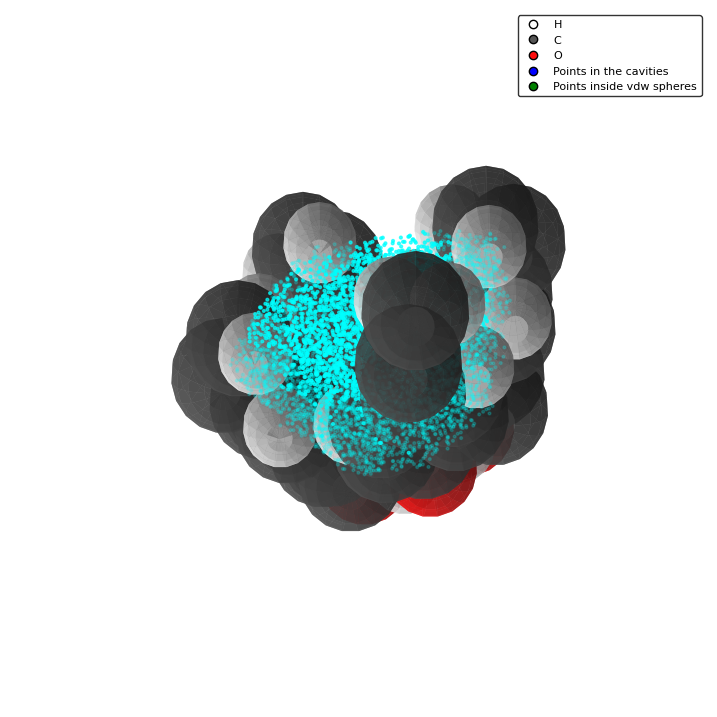

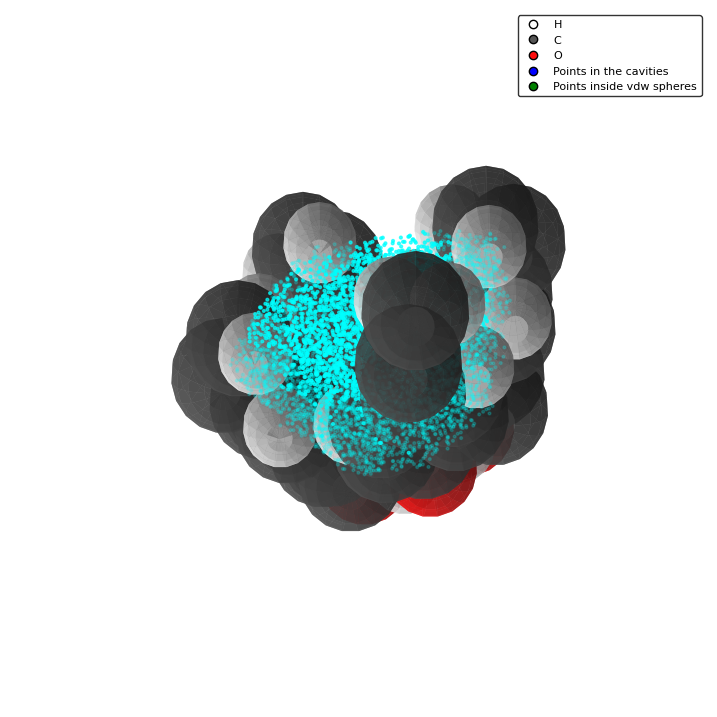

In [4]:
PointsInAtomsPlot(mol_data_1, plot_size=(8, 7), vdw_alpha=0.7, dot_size=4, dot_color_in_atoms='cyan', dot_color_cavities='cyan').plot(azim=360, elev=-64)

#  Dots in the cavities (indigo) and inside vdw spheres (green) for molecule 1

In [16]:
molecule_file = os.path.join(get_project_path(), 'CalixVolApp', 'data', 'molecules', 'txt_calix', f'1.txt')
mol_data_1 = init_parms(molecule_file)

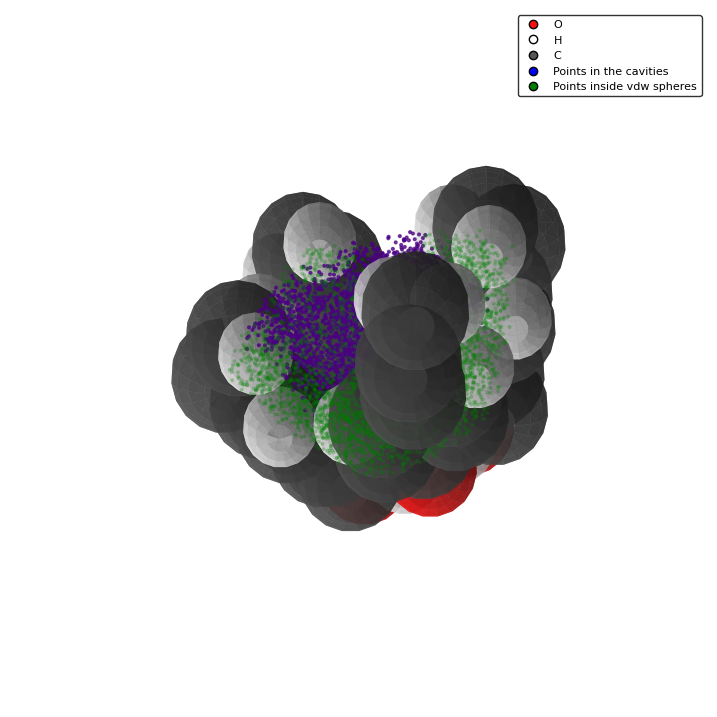

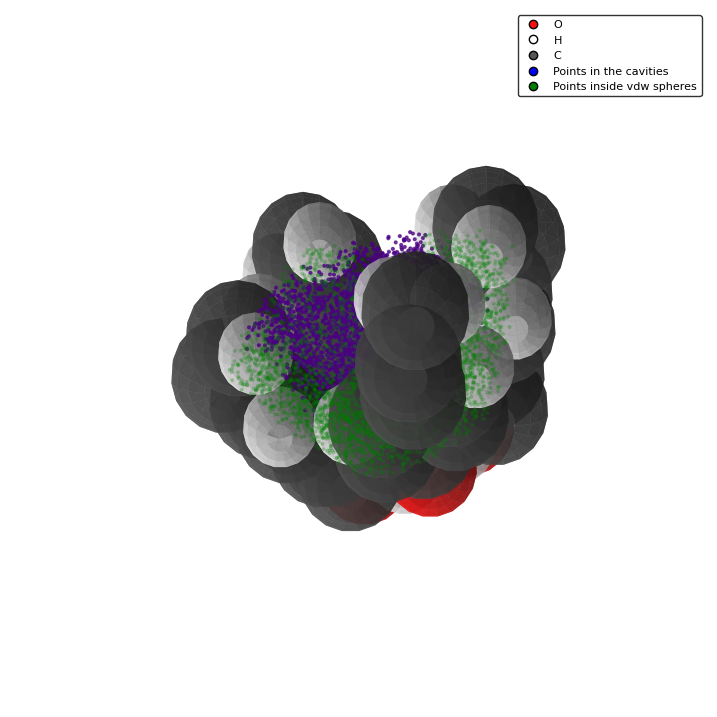

In [17]:
PointsInAtomsPlot(mol_data_1, plot_size=(8, 7), vdw_alpha=0.7, dot_size=4, dot_color_cavities='indigo').plot(azim=360, elev=-64)

# Visualization of the cavity volume of 1 molecule (without deleted atoms)

In [18]:
molecule_file = os.path.join(get_project_path(), 'CalixVolApp', 'data', 'molecules', 'txt_calix', f'1_w.o._delete_toms.txt')
mol_data_1 = init_parms(molecule_file)

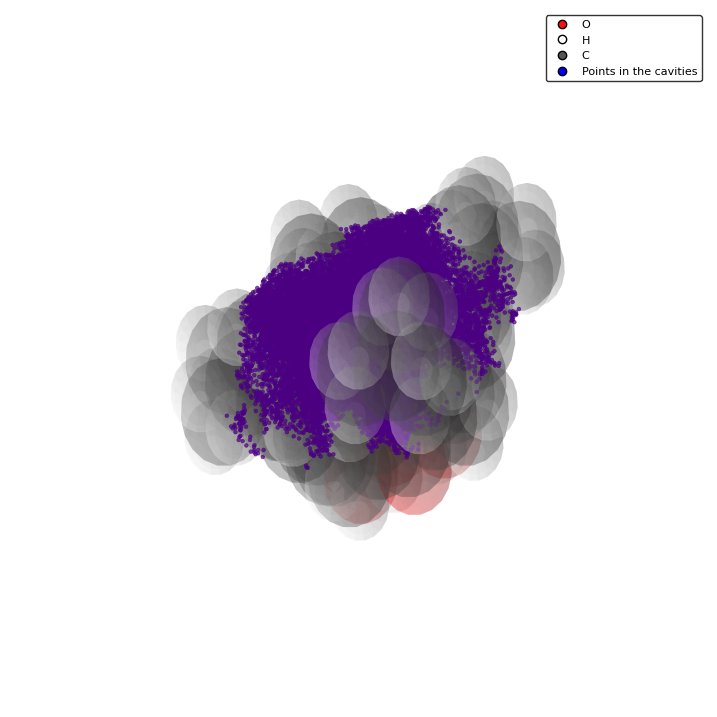

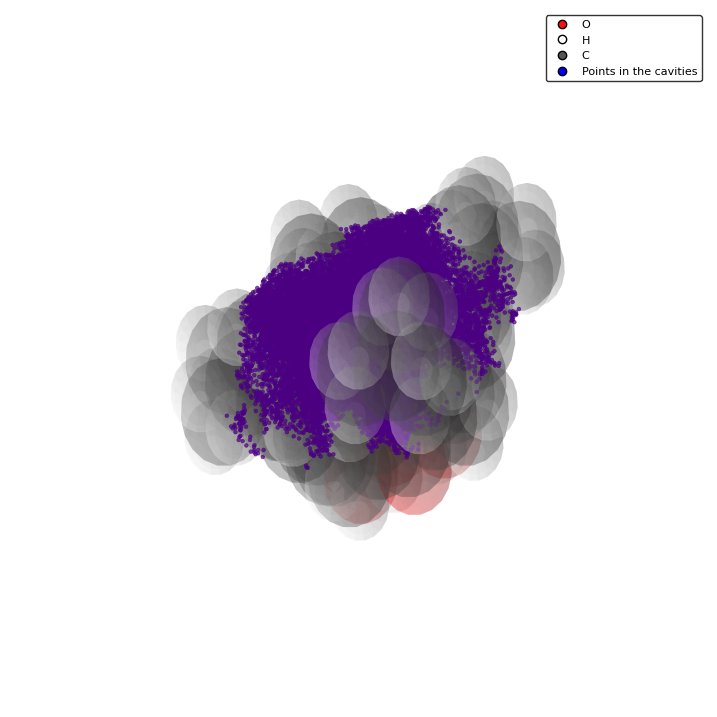

In [19]:
VisualizationCavityWithConvex(
    mol_data_1, 
    grid_resolution=0.1,
    show_hull=False,
    dot_color="indigo",
    dot_size=7.0,
    vdw_alpha=0.2,
    number_of_points=900000
).plot(azim=360, elev=-64)

# Visualization of the cavity volume of 1 molecule (with deleted atoms)

In [20]:
molecule_file = os.path.join(get_project_path(), 'CalixVolApp', 'data', 'molecules', 'txt_calix', f'1.txt')
mol_data_1 = init_parms(molecule_file)

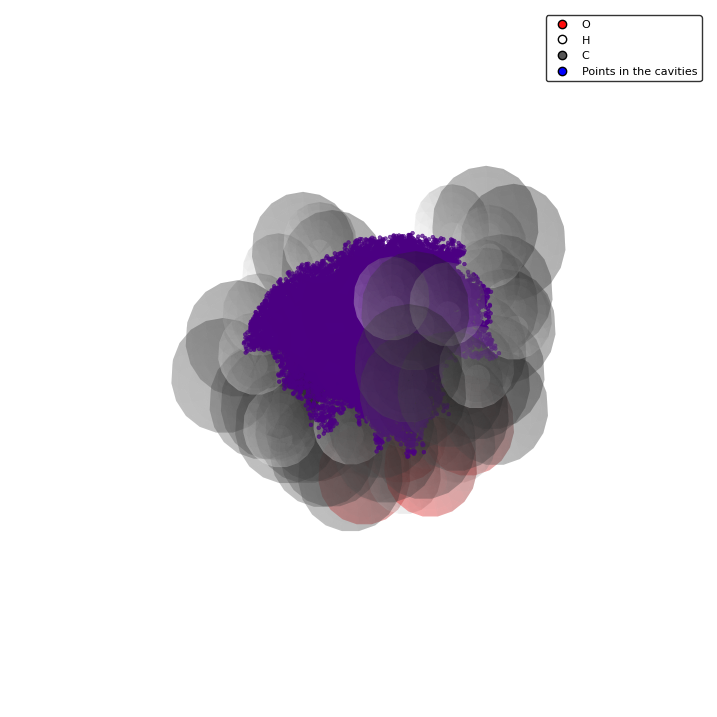

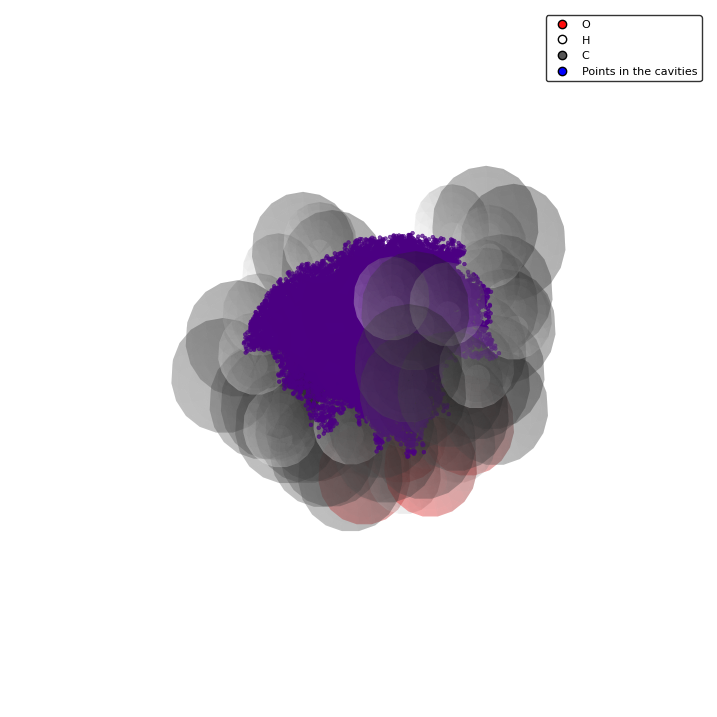

In [21]:
VisualizationCavityWithConvex(
    mol_data_1, 
    grid_resolution=0.1,
    show_hull=False,
    dot_color="indigo",
    dot_size=7.0,
    vdw_alpha=0.2,
    number_of_points=900000
).plot(azim=360, elev=-64)